In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import math
import matplotlib.pyplot as plt

In [2]:
def target_pdf(y):
    # ---------------------------------------------------------
    # STEP 1: THE BOUNDING BOX (16 Dimensions, from -5 to 5)
    # ---------------------------------------------------------
    x = -5.0 + 10.0 * torch.sigmoid(y)
    
    # ---------------------------------------------------------
    # STEP 2: TRACK THE SQUISH
    # ---------------------------------------------------------
    log_jac = math.log(10.0) + F.logsigmoid(y) + F.logsigmoid(-y)
    log_bounding_jac = log_jac.sum(dim=-1)
    
    # ---------------------------------------------------------
    # STEP 3: THE TOPOLOGICAL TRAP (Two Isolated Galaxies)
    # ---------------------------------------------------------
    # We make them incredibly sharp (sigma = 0.2)
    sigma = 0.2 
    
    # Galaxy A: Located at +2.5 on all 16 axes
    dist_A = ((x - 2.5)**2).sum(dim=-1)
    log_mode_A = -0.5 * (dist_A / sigma**2)
    
    # Galaxy B: Located at -2.5 on all 16 axes
    dist_B = ((x + 2.5)**2).sum(dim=-1)
    log_mode_B = -0.5 * (dist_B / sigma**2)
    
    # Combine them safely without causing numerical underflow (NaNs)
    log_f_phys = torch.logaddexp(log_mode_A, log_mode_B)
    
    # ---------------------------------------------------------
    # STEP 4: FINAL COMBINATION
    # ---------------------------------------------------------
    log_f_y = log_f_phys + log_bounding_jac
    return log_f_y

In [3]:
# ==========================================
# 2. THE MACHINE LEARNING ARCHITECTURE
# ==========================================
class AffineCouplingLayer(nn.Module):
    def __init__(self, dim, hidden_dim, mask):
        super().__init__()
        self.mask = mask
        self.mlp = nn.Sequential(
            nn.Linear(dim, hidden_dim),
            nn.LeakyReLU(0.01),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.01),
            nn.Linear(hidden_dim, dim * 2) 
        )
        
        # --- THE FIX: Identity Initialization ---
        # Force the final layer to output exactly 0.0 at the start of training.
        # This guarantees s=0 and t=0, preventing the space from exploding.
        nn.init.zeros_(self.mlp[-1].weight)
        nn.init.zeros_(self.mlp[-1].bias)

    def forward(self, z):
        z_A = z * self.mask
        s, t = self.mlp(z_A).chunk(2, dim=-1)
        
        # We can keep the clamp as an extra safety net
        s = torch.clamp(s, min=-5.0, max=5.0) 
        
        inv_mask = 1.0 - self.mask
        s = s * inv_mask
        t = t * inv_mask
        
        x = z_A + inv_mask * (z * torch.exp(s) + t)
        log_det = s.sum(dim=-1)
        return x, log_det

class NormalizingFlow(nn.Module):
    # SCALED UP FOR 16D: dim=16, and hidden_dim=256 to process the massive space
    def __init__(self, dim=16, num_layers=16, hidden_dim=256):
        super().__init__()
        self.layers = nn.ModuleList()
        for i in range(num_layers):
            
            # This dynamic mask automatically scales to 16 dimensions!
            mask = torch.zeros(dim)
            if i % 2 == 0:
                mask[::2] = 1.0  
            else:
                mask[1::2] = 1.0 
                
            self.layers.append(AffineCouplingLayer(dim, hidden_dim, mask))

    def forward(self, z):
        log_det_total = torch.zeros(z.shape[0], device=z.device)
        for layer in self.layers:
            layer.mask = layer.mask.to(z.device) 
            z, log_det = layer(z)
            log_det_total += log_det
        return z, log_det_total

In [4]:
def train_flow():
    dim = 16
    flow = NormalizingFlow(dim=dim, num_layers=16, hidden_dim=256)
    
    # Start with a slightly higher learning rate since the scheduler will shrink it
    optimizer = optim.Adam(flow.parameters(), lr=2e-3)
    
    epochs = 3000 
    batch_size = 8192 # Increased batch size for smoother gradients with a larger network
    
    # --- UPGRADE 1: Cosine Annealing Scheduler ---
    # Smoothly reduces the learning rate to 0 following a cosine curve
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    
    beta_start = 0.05       
    beta_end = 1.0          
    anneal_epochs = 2000
    
    # --- NEW: EARLY STOPPING TRACKERS ---
    best_loss = float('inf')
    patience_counter = 0
    patience_limit = 300  # How many epochs we tolerate no improvement
    
    print("Starting Training with Early Stopping Monitor...")
    
    for epoch in range(epochs):
        optimizer.zero_grad()
        
        beta = beta_start + (beta_end - beta_start) * min(1.0, epoch / anneal_epochs)
            
        z = torch.randn(batch_size, dim)
        log_p_z = -0.5 * (z**2).sum(dim=-1) - (dim / 2.0) * math.log(2 * math.pi)
        
        x, log_det = flow(z)
        log_q_x = log_p_z - log_det
        log_f_x = target_pdf(x)
        
        loss = (log_q_x - beta * log_f_x).mean()
        loss.backward()
        
        # --- UPGRADE 2: Gradient Clipping ---
        # Prevents exploding gradients (NaNs) by capping the maximum gradient vector length at 1.0
        nn.utils.clip_grad_norm_(flow.parameters(), max_norm=1.0)
        
        optimizer.step()
        scheduler.step() # Tell the scheduler to update the learning rate
        
        current_loss = loss.item()
        current_lr = scheduler.get_last_lr()[0]
        
        if epoch % 400 == 0:
            print(f"Epoch {epoch:4d} | Beta: {beta:.3f} | LR: {current_lr:.5f} | Loss: {current_loss:.4f}")
            
        # =========================================================
        # THE EARLY STOPPING MONITOR
        # =========================================================
        # Rule 1: Only start tracking AFTER the physics is fully sharpened
        if epoch > anneal_epochs:
            
            # Rule 2: Check if the loss genuinely improved
            if current_loss < best_loss - 1e-4:
                best_loss = current_loss
                patience_counter = 0  # Reset the clock!
            else:
                patience_counter += 1 # Tick the clock
                
            # Rule 3: Pull the plug if we hit the limit
            if patience_counter >= patience_limit:
                print(f"\n[EARLY STOPPING TRIGGERED]")
                print(f"Loss completely flatlined for {patience_limit} epochs.")
                print(f"Training successfully terminated early at Epoch {epoch} to save time.")
                break # This instantly shatters the for-loop

    return flow

In [5]:
# ==========================================
# 4. UPGRADED PLOTTING (Physical Variables)
# ==========================================
def integrate_and_plot(flow, num_samples=5000000): # High samples for smooth physics
    print("\nStarting Physics Integration...")
    dim = 16
    flow.eval()
    with torch.no_grad():
        z = torch.randn(num_samples, dim)
        log_p_z = -0.5 * (z**2).sum(dim=-1) - (dim / 2.0) * math.log(2 * math.pi)
        
        y, log_det = flow(z)
        log_q_y = log_p_z - log_det
        log_f_y = target_pdf(y)
        
        weights = torch.exp(log_f_y - log_q_y)
        
        integral = weights.mean().item()
        variance = weights.var().item()
        error = math.sqrt(variance / num_samples)
        
        print(f"Calculated Integral : {integral:.8f} +/- {error:.8f}")
        print(f"Variance (sigma^2)  : {variance:.8f}")
        
        sig_y0 = torch.sigmoid(y[:, 0])
        sig_y1 = torch.sigmoid(y[:, 1])
        x0 = -5.0 + 10.0 * sig_y0
        x1 = -5.0 + 10.0 * sig_y1
        
        x0_np = x0.numpy()
        x1_np = x1.numpy()
    
    # Generate the Rosenbrock Banana Plot
    # Generate the 16D Topological Trap Plot
    plt.figure(figsize=(8, 8)) # Changed to a perfect square to match the bounding box
    
    # --- THE FIX: Zoom out to see the whole [-5, 5] universe ---
    plt.hist2d(x0_np, x1_np, bins=150, cmap='magma', range=[[-5, 5], [-5, 5]])
    plt.colorbar(label='Generated Density')
    
    # --- UPGRADE: Draw crosshairs so we can easily spot the galaxies ---
    plt.axvline(2.5, color='white', linestyle='--', alpha=0.3)
    plt.axhline(2.5, color='white', linestyle='--', alpha=0.3)
    plt.axvline(-2.5, color='white', linestyle='--', alpha=0.3)
    plt.axhline(-2.5, color='white', linestyle='--', alpha=0.3)
    
    plt.title("Learned 16D Topological Trap (Dimensions 0 and 1)")
    plt.xlabel("$X_0$")
    plt.ylabel("$X_1$")
    plt.show()

In [6]:
trained_model = train_flow()

Starting Training with Early Stopping Monitor...
Epoch    0 | Beta: 0.050 | LR: 0.01000 | Loss: 61.5816
Epoch  400 | Beta: 0.240 | LR: 0.00957 | Loss: 7.1019
Epoch  800 | Beta: 0.430 | LR: 0.00834 | Loss: 9.9776
Epoch 1200 | Beta: 0.620 | LR: 0.00654 | Loss: 11.0334
Epoch 1600 | Beta: 0.810 | LR: 0.00447 | Loss: 11.2872
Epoch 2000 | Beta: 1.000 | LR: 0.00250 | Loss: 11.0726
Epoch 2400 | Beta: 1.000 | LR: 0.00095 | Loss: 11.0573

[EARLY STOPPING TRIGGERED]
Loss completely flatlined for 300 epochs.
Training successfully terminated early at Epoch 2672 to save time.



Starting Physics Integration...
Calculated Integral : 0.00001592 +/- 0.00000000
Variance (sigma^2)  : 0.00000000


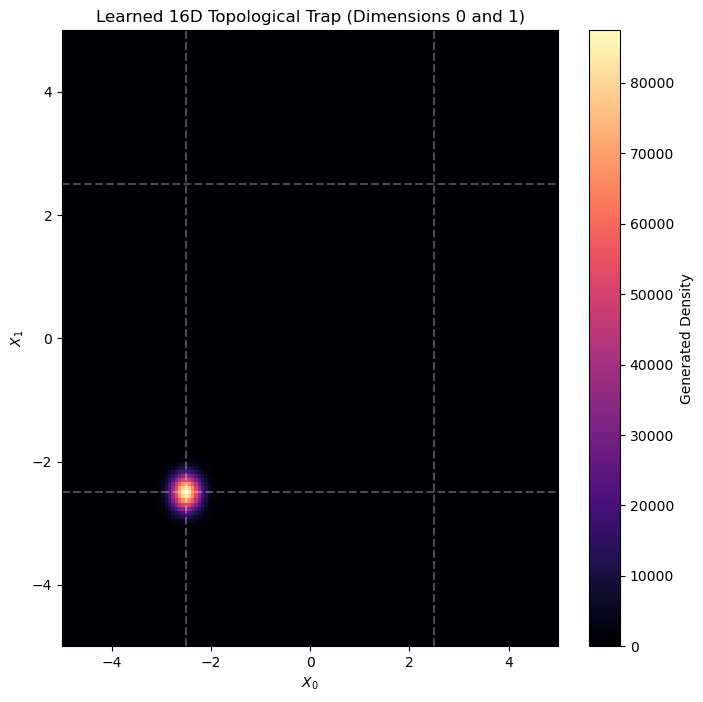

In [7]:
integrate_and_plot(trained_model)